# Vision Studio Segmentation Training and Compression Evaluation

This notebook fine-tunes a pretrained semantic segmentation model on the Amazon Forest Dataset using `vision_studio.trainer.VisionTrainer`, evaluates with `vision_studio.evaluate.LoopEvaluator`, and compares original images against autoencoder, JPEG, and WebP compression variants. Generated checkpoints, metadata, tables, plots, and examples are written under `notebooks/outputs/image_segmentation/`; source datasets and `/home/mozi30/data/models/autoencoder` are read-only inputs.

## Imports and Project Setup

Load standard utilities, PyTorch and torchvision helpers, then expose the local `vision_studio` package and import its segmentation dataset, model adapter, trainer, evaluator, metrics, and shared types.

In [1]:
from __future__ import annotations

import csv
import json
import math
import os
import random
import re
import sys
import time
from dataclasses import dataclass
from io import BytesIO
from pathlib import Path
from typing import Any, Callable

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display
from PIL import Image
from torch import Tensor
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset as TorchDataset
from torchvision.transforms import functional as TVF

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists():
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from vision_studio.dataset import (
    AmazonForestSegmentationDataset,
    SegmentationEvaluationVariantDataset,
)
from vision_studio.evaluate import LoopEvaluator, SegmentationEvaluationMetrics
from vision_studio.models import (
    BaseModel,
    SegmentationModelAdapter,
    create_torchvision_segmentation_model,
)
from vision_studio.trainer import VisionTrainer
from vision_studio.types import InputSpec, LossOutput, OutputSpec, PostprocessOutput, TrainerSettings


## Optional Diffusers VAE Probe

This standalone probe loads a pretrained Stable Diffusion VAE and verifies its encode/decode interface with a synthetic image. It is exploratory and is not used by the main Vision Studio benchmark below.

In [2]:
import torch
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained(
    "stabilityai/sd-vae-ft-mse",
    torch_dtype=torch.float32
).eval().cuda()
# image: tensor [B, 3, H, W], values in [-1, 1]
image = torch.randn(1, 3, 512, 512).cuda()
with torch.no_grad():
    latent = vae.encode(image).latent_dist.mean
    recon = vae.decode(latent).sample

/home/mozi30/repos/private/CV_VisionStudio/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mozi30/repos/private/CV_VisionStudio/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


## Run Configuration and Output Paths

Resolve dataset splits, checkpoint and artifact directories, quick/full run limits, training hyperparameters, compression quality levels, random seeds, device selection, and pretrained segmentation model settings.

In [3]:
DATASET_PATH = Path(os.getenv("SEGMENTATION_DATASET_PATH", "/home/mozi30/data/datasets/Amazon Forest Dataset"))
TRAIN_SPLIT = os.getenv("SEGMENTATION_TRAIN_SPLIT", "Training")
VAL_SPLIT = os.getenv("SEGMENTATION_VAL_SPLIT", "Validation")
TEST_SPLIT = os.getenv("SEGMENTATION_TEST_SPLIT", "Test")
AUTOENCODER_DIR = Path(os.getenv("SEGMENTATION_AUTOENCODER_DIR", "/home/mozi30/data/models/autoencoder"))
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "outputs" / "image_segmentation"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
VISUAL_DIR = OUTPUT_DIR / "visual_examples"

RUN_MODE = os.getenv("SEGMENTATION_RUN_MODE", "full")
QUICK_RUN_LIMIT = int(os.getenv("SEGMENTATION_QUICK_RUN_LIMIT", "3"))
QUICK_RUN_TRAIN_LIMIT = int(os.getenv("SEGMENTATION_QUICK_RUN_TRAIN_LIMIT", str(QUICK_RUN_LIMIT)))
QUICK_RUN_AUTOENCODER_LIMIT = int(os.getenv("SEGMENTATION_QUICK_RUN_AUTOENCODER_LIMIT", "1"))
EPOCHS = int(os.getenv("SEGMENTATION_EPOCHS", "1" if RUN_MODE == "quick" else "20"))
BATCH_SIZE = int(os.getenv("SEGMENTATION_BATCH_SIZE", "1" if RUN_MODE == "quick" else "2"))
LEARNING_RATE = float(os.getenv("SEGMENTATION_LR", "1e-4"))
RANDOM_SEED = int(os.getenv("SEGMENTATION_SEED", "42"))

BASE_MODEL_ID = os.getenv("SEGMENTATION_MODEL_ID", "fcn_resnet50")
BASE_MODEL_WEIGHT_ID = os.getenv("SEGMENTATION_MODEL_WEIGHTS", "DEFAULT")
REQUIRE_PRETRAINED_WEIGHTS = os.getenv("SEGMENTATION_REQUIRE_PRETRAINED", "1") != "0"
IGNORE_INDEX: int | None = None

JPEG_WEBP_QUALITY_LEVELS = {"low": 35, "medium": 65, "high": 90}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
VISUAL_DIR.mkdir(parents=True, exist_ok=True)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if RUN_MODE not in {"quick", "full"}:
    raise ValueError("SEGMENTATION_RUN_MODE must be 'quick' or 'full'.")

display(Markdown(f"""
**Run configuration**

- Dataset root: `{DATASET_PATH}`
- Train split: `{TRAIN_SPLIT}`; validation split: `{VAL_SPLIT}`; test split: `{TEST_SPLIT}`
- Autoencoder checkpoints: `{AUTOENCODER_DIR}`
- Output directory: `{OUTPUT_DIR}`
- Run mode: `{RUN_MODE}`; epochs: `{EPOCHS}`; batch size: `{BATCH_SIZE}`
- Device: `{DEVICE}`
- Segmentation model: `torchvision/{BASE_MODEL_ID}:{BASE_MODEL_WEIGHT_ID if REQUIRE_PRETRAINED_WEIGHTS else 'none'}`
- Fine-tuning scope: entire pretrained model; quick mode limits data/epochs, not trainable parameters
"""))



**Run configuration**

- Dataset root: `/home/mozi30/data/datasets/Amazon Forest Dataset`
- Train split: `Training`; validation split: `Validation`; test split: `Test`
- Autoencoder checkpoints: `/home/mozi30/data/models/autoencoder`
- Output directory: `/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation`
- Run mode: `full`; epochs: `20`; batch size: `2`
- Device: `cuda`
- Segmentation model: `torchvision/fcn_resnet50:DEFAULT`
- Fine-tuning scope: entire pretrained model; quick mode limits data/epochs, not trainable parameters


## Package-Backed Dataset Setup

The Amazon Forest train and validation splits are loaded through `AmazonForestSegmentationDataset`. Quick mode restricts sample counts through the dataset `limit` parameter so the same package dataset contract is used in smoke and full runs.

In [4]:
def normalize_image(image: Tensor) -> Tensor:
    image = image.float().clamp(0.0, 1.0)
    if image.shape[0] == 1:
        image = image.repeat(3, 1, 1)
    if image.shape[0] > 3:
        image = image[:3]
    return TVF.normalize(image, (0.485, 0.456, 0.406), (0.229, 0.224, 0.225))


train_limit = QUICK_RUN_TRAIN_LIMIT if RUN_MODE == "quick" else None
val_limit = QUICK_RUN_LIMIT if RUN_MODE == "quick" else None
test_limit = QUICK_RUN_LIMIT if RUN_MODE == "quick" else None
raw_train_dataset = AmazonForestSegmentationDataset(
    DATASET_PATH,
    split=TRAIN_SPLIT,
    ignore_index=IGNORE_INDEX,
    limit=train_limit,
)
raw_val_dataset = AmazonForestSegmentationDataset(
    DATASET_PATH,
    split=VAL_SPLIT,
    num_classes=raw_train_dataset.get_num_classes(),
    ignore_index=IGNORE_INDEX,
    limit=val_limit,
)
# test_dataset = AmazonForestSegmentationDataset(
#     DATASET_PATH,
#     split=TEST_SPLIT,
#     num_classes=raw_train_dataset.get_num_classes(),
#     ignore_index=IGNORE_INDEX,
#     limit=test_limit,
# )
num_classes = raw_train_dataset.get_num_classes()

train_dataset = SegmentationEvaluationVariantDataset(raw_train_dataset, lambda image, target: normalize_image(image))
val_dataset = SegmentationEvaluationVariantDataset(raw_val_dataset, lambda image, target: normalize_image(image))
#test_dataset = SegmentationEvaluationVariantDataset(test_dataset, lambda image, target: normalize_image(image))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
#test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

display(Markdown(f"""
**Dataset validation**

- Training samples selected: `{len(raw_train_dataset)}`
- Validation samples selected: `{len(raw_val_dataset)}`
- Class count: `{num_classes}`
- Image size: `{raw_train_dataset.get_image_size()}`
- Class pixel counts: `{raw_train_dataset.get_class_sample_counts()}`
"""))



**Dataset validation**

- Training samples selected: `30`
- Validation samples selected: `15`
- Class count: `2`
- Image size: `(512, 512)`
- Class pixel counts: `{0: 3658952, 1: 4206904}`


## Autoencoder and Compression Helpers

Compression-specific code remains local to the notebook. These helpers only transform evaluation images; labels, model, and metrics stay shared across every variant.

In [5]:
class EncoderBlock(torch.nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = torch.nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.batch_norm = torch.nn.BatchNorm2d(out_channels)
        self.pool = torch.nn.MaxPool2d(2, ceil_mode=True)

    def forward(self, x: Tensor) -> Tensor:
        return self.pool(torch.relu(self.batch_norm(self.conv(x))))


class DecoderBlock(torch.nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = torch.nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.batch_norm = torch.nn.BatchNorm2d(out_channels)

    def forward(self, x: Tensor) -> Tensor:
        return torch.relu(self.batch_norm(self.conv(x)))


class Autoencoder(BaseModel):
    def __init__(self, encoder_depth: int, input_size: tuple[int, int, int], base_channels: int, device: torch.device):
        super().__init__()
        self._input_spec = InputSpec(shape=input_size, dtype=torch.float32, device=device)
        self._output_spec = OutputSpec(shape=input_size, dtype=torch.float32)
        in_channels = input_size[0]
        encoder_channels = [in_channels] + [base_channels * (2 ** i) for i in range(encoder_depth)]
        self.encoder_blocks = torch.nn.ModuleList([
            EncoderBlock(encoder_channels[i], encoder_channels[i + 1])
            for i in range(encoder_depth)
        ])
        decoder_channels = list(reversed(encoder_channels[1:]))
        self.decoder_blocks = torch.nn.ModuleList([
            DecoderBlock(decoder_channels[i], decoder_channels[i + 1])
            for i in range(max(encoder_depth - 1, 0))
        ])
        self.reconstruction = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(decoder_channels[-1], base_channels, kernel_size=2, stride=2),
            torch.nn.ReLU(),
            torch.nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1),
            torch.nn.Sigmoid(),
        )
        self.to(device)

    @property
    def input_spec(self) -> InputSpec:
        return self._input_spec

    @property
    def output_spec(self) -> OutputSpec:
        return self._output_spec

    def forward(self, inputs: Tensor) -> Tensor:
        x = inputs
        for block in self.encoder_blocks:
            x = block(x)
        for block in self.decoder_blocks:
            x = block(x)
        x = self.reconstruction(x)
        return torch.nn.functional.interpolate(x, size=inputs.shape[-2:], mode="bilinear", align_corners=False)

    def postprocess(self, logits: Tensor) -> PostprocessOutput:
        return PostprocessOutput(logits=logits)

    def compute_loss(self, logits: Tensor, targets: dict[str, Any]) -> LossOutput:
        return LossOutput(loss=torch.nn.functional.mse_loss(logits, targets["inputs"]))


class ConvBlock(torch.nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, out_channels, 3, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(out_channels, out_channels, 3, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)


class DownBlock(torch.nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, out_channels, 4, stride=2, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
            ConvBlock(out_channels, out_channels),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)


class UpBlock(torch.nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            torch.nn.Conv2d(in_channels, out_channels, 3, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
            ConvBlock(out_channels, out_channels),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)


class BetterAutoencoder(BaseModel):
    def __init__(
        self,
        encoder_depth: int,
        input_size: tuple[int, int, int],
        base_channels: int,
        latent_channels: int,
        device: torch.device,
        add_latent_noise: bool = False,
    ):
        super().__init__()
        self._input_spec = InputSpec(shape=input_size, dtype=torch.float32, device=device)
        self._output_spec = OutputSpec(shape=input_size, dtype=torch.float32)
        self.add_latent_noise = add_latent_noise
        in_channels = input_size[0]
        channels = [base_channels * (2 ** i) for i in range(encoder_depth)]

        self.stem = ConvBlock(in_channels, channels[0])
        self.encoder = torch.nn.ModuleList([
            DownBlock(channels[i], channels[i + 1])
            for i in range(encoder_depth - 1)
        ])
        bottleneck_channels = channels[-1]
        self.to_latent = torch.nn.Sequential(
            torch.nn.Conv2d(bottleneck_channels, latent_channels, kernel_size=1),
            torch.nn.Tanh(),
        )
        self.from_latent = torch.nn.Sequential(
            torch.nn.Conv2d(latent_channels, bottleneck_channels, kernel_size=1),
            torch.nn.ReLU(inplace=True),
        )
        decoder_channels = list(reversed(channels))
        self.decoder = torch.nn.ModuleList([
            UpBlock(decoder_channels[i], decoder_channels[i + 1])
            for i in range(len(decoder_channels) - 1)
        ])
        self.reconstruction = torch.nn.Sequential(
            torch.nn.Conv2d(channels[0], channels[0], 3, padding=1),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(channels[0], in_channels, 3, padding=1),
            torch.nn.Sigmoid(),
        )
        self.to(device)

    @property
    def input_spec(self) -> InputSpec:
        return self._input_spec

    @property
    def output_spec(self) -> OutputSpec:
        return self._output_spec

    def encode(self, inputs: Tensor) -> Tensor:
        x = self.stem(inputs)
        for block in self.encoder:
            x = block(x)
        z = self.to_latent(x)
        if self.training and self.add_latent_noise:
            z = z + torch.empty_like(z).uniform_(-1 / 255, 1 / 255)
        return z

    def decode(self, latent: Tensor, output_size: tuple[int, int]) -> Tensor:
        x = self.from_latent(latent)
        for block in self.decoder:
            x = block(x)
        x = self.reconstruction(x)
        if x.shape[-2:] != output_size:
            x = torch.nn.functional.interpolate(x, size=output_size, mode="bilinear", align_corners=False)
        return x

    def forward(self, inputs: Tensor) -> Tensor:
        return self.decode(self.encode(inputs), inputs.shape[-2:])

    def postprocess(self, logits: Tensor) -> PostprocessOutput:
        return PostprocessOutput(logits=logits)

    def compute_loss(self, logits: Tensor, targets: dict[str, Any]) -> LossOutput:
        inputs = targets["inputs"]
        loss = 0.8 * torch.nn.functional.l1_loss(logits, inputs) + 0.2 * torch.nn.functional.mse_loss(logits, inputs)
        return LossOutput(loss=loss)


class QuantizedResBlock(torch.nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(channels),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(channels),
        )

    def forward(self, x: Tensor) -> Tensor:
        return torch.nn.functional.relu(x + self.net(x), inplace=True)


class QuantizedDownBlock(torch.nn.Module):
    def __init__(self, in_channels: int, out_channels: int, num_res_blocks: int):
        super().__init__()
        self.down = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
        )
        self.res_blocks = torch.nn.Sequential(
            *[QuantizedResBlock(out_channels) for _ in range(num_res_blocks)]
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.res_blocks(self.down(x))


class QuantizedUpBlock(torch.nn.Module):
    def __init__(self, in_channels: int, out_channels: int, num_res_blocks: int):
        super().__init__()
        self.up = torch.nn.Sequential(
            torch.nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            torch.nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
        )
        self.res_blocks = torch.nn.Sequential(
            *[QuantizedResBlock(out_channels) for _ in range(num_res_blocks)]
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.res_blocks(self.up(x))


class QuantizedCompressiveAutoencoder(BaseModel):
    def __init__(
        self,
        encoder_depth: int,
        input_size: tuple[int, int, int],
        base_channels: int,
        latent_channels: int,
        num_res_blocks: int,
        quantization_levels: int,
        rate_weight: float,
        device: torch.device,
    ):
        super().__init__()
        self._input_spec = InputSpec(shape=input_size, dtype=torch.float32, device=device)
        self._output_spec = OutputSpec(shape=input_size, dtype=torch.float32)
        self.quantization_levels = quantization_levels
        self.rate_weight = rate_weight
        in_channels = input_size[0]
        channels = [base_channels * (2 ** i) for i in range(encoder_depth)]
        self.stem = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, channels[0], kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(channels[0]),
            torch.nn.ReLU(inplace=True),
            QuantizedResBlock(channels[0]),
        )
        self.encoder = torch.nn.ModuleList([
            QuantizedDownBlock(channels[i], channels[i + 1], num_res_blocks)
            for i in range(encoder_depth - 1)
        ])
        bottleneck_channels = channels[-1]
        self.to_latent = torch.nn.Sequential(
            torch.nn.Conv2d(bottleneck_channels, latent_channels, kernel_size=1),
            torch.nn.Tanh(),
        )
        self.from_latent = torch.nn.Sequential(
            torch.nn.Conv2d(latent_channels, bottleneck_channels, kernel_size=1),
            torch.nn.BatchNorm2d(bottleneck_channels),
            torch.nn.ReLU(inplace=True),
        )
        decoder_channels = list(reversed(channels))
        self.decoder = torch.nn.ModuleList([
            QuantizedUpBlock(decoder_channels[i], decoder_channels[i + 1], num_res_blocks)
            for i in range(len(decoder_channels) - 1)
        ])
        self.reconstruction = torch.nn.Sequential(
            torch.nn.Conv2d(channels[0], channels[0], kernel_size=3, padding=1),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(channels[0], in_channels, kernel_size=3, padding=1),
            torch.nn.Sigmoid(),
        )
        self._last_quantized_latent: Tensor | None = None
        self.to(device)

    @property
    def input_spec(self) -> InputSpec:
        return self._input_spec

    @property
    def output_spec(self) -> OutputSpec:
        return self._output_spec

    def quantize_straight_through(self, latent: Tensor) -> Tensor:
        levels = self.quantization_levels
        scaled = (latent + 1.0) * 0.5 * (levels - 1)
        quantized = (torch.round(scaled) / (levels - 1)) * 2.0 - 1.0
        return latent + (quantized - latent).detach()

    def encode(self, inputs: Tensor) -> Tensor:
        x = self.stem(inputs)
        for block in self.encoder:
            x = block(x)
        latent = self.quantize_straight_through(self.to_latent(x))
        self._last_quantized_latent = latent
        return latent

    def decode(self, latent: Tensor, output_size: tuple[int, int]) -> Tensor:
        x = self.from_latent(latent)
        for block in self.decoder:
            x = block(x)
        x = self.reconstruction(x)
        if x.shape[-2:] != output_size:
            x = torch.nn.functional.interpolate(x, size=output_size, mode="bilinear", align_corners=False)
        return x

    def forward(self, inputs: Tensor) -> Tensor:
        return self.decode(self.encode(inputs), inputs.shape[-2:])

    def postprocess(self, logits: Tensor) -> PostprocessOutput:
        return PostprocessOutput(logits=logits)

    def compute_loss(self, logits: Tensor, targets: dict[str, Any]) -> LossOutput:
        inputs = targets["inputs"]
        reconstruction_loss = 0.85 * torch.nn.functional.l1_loss(logits, inputs) + 0.15 * torch.nn.functional.mse_loss(logits, inputs)
        rate_loss = torch.tensor(0.0, device=logits.device) if self._last_quantized_latent is None else self._last_quantized_latent.abs().mean()
        return LossOutput(loss=reconstruction_loss + self.rate_weight * rate_loss)


LEGACY_AUTOENCODER_PATTERN = re.compile(r"encoder_depth_(?P<depth>\d+)_base_channel_(?P<channels>\d+)\.pth$")
LATENT_AUTOENCODER_PATTERN = re.compile(r"base_(?P<channels>\d+)_latent_(?P<latent>\d+)\.pt$")
QUANTIZED_AUTOENCODER_PATTERN = re.compile(r"rate_(?P<rate>\d+(?:\.\d+)?)_latent_(?P<latent>\d+)\.pt$")


@dataclass(frozen=True)
class AutoencoderCheckpoint:
    path: Path
    name: str
    architecture: str
    encoder_depth: int
    base_channels: int
    latent_channels: int | None = None
    rate_weight: float | None = None

    @property
    def setting(self) -> str:
        parts = [f"architecture={self.architecture}", f"depth={self.encoder_depth}", f"base_channels={self.base_channels}"]
        if self.latent_channels is not None:
            parts.append(f"latent_channels={self.latent_channels}")
        if self.rate_weight is not None:
            parts.append(f"rate_weight={self.rate_weight:g}")
        return ";".join(parts)


AutoencoderModel = Autoencoder | BetterAutoencoder | QuantizedCompressiveAutoencoder


def safe_error(exc: BaseException) -> str:
    first_line = str(exc).splitlines()[0] if str(exc) else exc.__class__.__name__
    return f"{exc.__class__.__name__}: {first_line[:240]}"


def discover_autoencoder_checkpoints(directory: Path) -> list[AutoencoderCheckpoint]:
    if not directory.exists():
        return []
    checkpoints: list[AutoencoderCheckpoint] = []
    for path in sorted([*directory.glob("*.pth"), *directory.glob("*.pt")]):
        legacy_match = LEGACY_AUTOENCODER_PATTERN.fullmatch(path.name)
        if legacy_match:
            checkpoints.append(AutoencoderCheckpoint(
                path=path,
                name=path.stem,
                architecture="legacy",
                encoder_depth=int(legacy_match.group("depth")),
                base_channels=int(legacy_match.group("channels")),
            ))
            continue
        latent_match = LATENT_AUTOENCODER_PATTERN.fullmatch(path.name)
        if latent_match:
            checkpoints.append(AutoencoderCheckpoint(
                path=path,
                name=path.stem,
                architecture="latent",
                encoder_depth=4,
                base_channels=int(latent_match.group("channels")),
                latent_channels=int(latent_match.group("latent")),
            ))
            continue
        quantized_match = QUANTIZED_AUTOENCODER_PATTERN.fullmatch(path.name)
        if quantized_match:
            checkpoints.append(AutoencoderCheckpoint(
                path=path,
                name=path.stem,
                architecture="quantized_compressive",
                encoder_depth=4,
                base_channels=32,
                latent_channels=int(quantized_match.group("latent")),
                rate_weight=float(quantized_match.group("rate")),
            ))
    return sorted(checkpoints, key=lambda checkpoint: (checkpoint.architecture, checkpoint.base_channels, checkpoint.rate_weight or -1.0, checkpoint.latent_channels or -1, checkpoint.encoder_depth, checkpoint.name))


def load_autoencoder(checkpoint: AutoencoderCheckpoint, input_size: tuple[int, int, int]) -> AutoencoderModel:
    if checkpoint.architecture == "quantized_compressive":
        if checkpoint.latent_channels is None or checkpoint.rate_weight is None:
            raise ValueError(f"Missing quantized model metadata for {checkpoint.path.name}")
        model: AutoencoderModel = QuantizedCompressiveAutoencoder(
            encoder_depth=checkpoint.encoder_depth,
            input_size=input_size,
            base_channels=checkpoint.base_channels,
            latent_channels=checkpoint.latent_channels,
            num_res_blocks=2,
            quantization_levels=256,
            rate_weight=checkpoint.rate_weight,
            device=DEVICE,
        )
    elif checkpoint.architecture == "latent":
        if checkpoint.latent_channels is None:
            raise ValueError(f"Missing latent channel count for {checkpoint.path.name}")
        model: AutoencoderModel = BetterAutoencoder(
            encoder_depth=checkpoint.encoder_depth,
            input_size=input_size,
            base_channels=checkpoint.base_channels,
            latent_channels=checkpoint.latent_channels,
            device=DEVICE,
        )
    else:
        model = Autoencoder(checkpoint.encoder_depth, input_size, checkpoint.base_channels, DEVICE)
    payload = torch.load(checkpoint.path, map_location=DEVICE)
    state_dict = payload.get("model_state_dict", payload) if isinstance(payload, dict) else payload
    model.load_state_dict(state_dict)
    model.eval()
    return model


@torch.no_grad()
def autoencode_image(image: Tensor, autoencoder: AutoencoderModel) -> Tensor:
    return autoencoder(image.unsqueeze(0).to(DEVICE)).squeeze(0).detach().cpu().clamp(0.0, 1.0)


def tensor_to_pil_rgb(image: Tensor) -> Image.Image:
    return TVF.to_pil_image(image.detach().cpu().float().clamp(0.0, 1.0))


def compress_with_pillow(image: Tensor, method: str, quality: int) -> Tensor:
    buffer = BytesIO()
    fmt = "JPEG" if method == "jpeg" else "WEBP"
    kwargs = {"quality": int(quality)}
    if fmt == "JPEG":
        kwargs["optimize"] = True
    tensor_to_pil_rgb(image).save(buffer, format=fmt, **kwargs)
    buffer.seek(0)
    decoded = Image.open(buffer).convert("RGB")
    tensor = TVF.to_tensor(decoded).float().clamp(0.0, 1.0)
    if tensor.shape != image.shape:
        raise ValueError(f"{fmt} round-trip changed shape from {tuple(image.shape)} to {tuple(tensor.shape)}")
    return tensor


## Whole-Model Fine-Tuning Through Vision Studio Trainer

The model is created through the Vision Studio segmentation adapter and trained with `VisionTrainer.fit`. Checkpoints are generated under the notebook output directory.

In [6]:
weights_arg = BASE_MODEL_WEIGHT_ID if REQUIRE_PRETRAINED_WEIGHTS else None
try:
    model = create_torchvision_segmentation_model(
        BASE_MODEL_ID,
        num_classes=num_classes,
        weights=weights_arg,
        ignore_index=IGNORE_INDEX,
    )
except Exception as exc:
    if REQUIRE_PRETRAINED_WEIGHTS:
        raise RuntimeError(f"Could not load pretrained segmentation model: {safe_error(exc)}") from exc
    raise

model.to(DEVICE)
trainable_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
total_params = sum(parameter.numel() for parameter in model.parameters())
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
evaluator = LoopEvaluator(
    SegmentationEvaluationMetrics(num_classes=num_classes, ignore_index=IGNORE_INDEX),
    device=DEVICE,
)
trainer = VisionTrainer(
    optimizer=optimizer,
    evaluator=evaluator,
    device=DEVICE,
    settings=TrainerSettings(
        epochs=EPOCHS,
        checkpoint_path=CHECKPOINT_DIR,
        save_latest_checkpoint=True,
        checkpoint_monitor="loss",
        checkpoint_mode="min",
        best_checkpoint_count=1,
    ),
)

start = time.perf_counter()
training_result = trainer.fit(model, EPOCHS, train_loader, val_loader)
training_seconds = time.perf_counter() - start
checkpoint_paths = [str(info.path) for info in training_result.get("checkpoints", [])]

display(Markdown(f"""
**Training complete**

- Model id: `{BASE_MODEL_ID}`
- Weights id: `{weights_arg}`
- Trainable parameters: `{trainable_params}` / `{total_params}`
- Epochs completed: `{len(training_result['history']['train'])}`
- Latest train loss: `{training_result['history']['train'][-1]['loss']:.4f}`
- Latest evaluation loss: `{training_result['history']['evaluation'][-1]['loss']:.4f}`
- Checkpoints: `{checkpoint_paths}`
- Runtime seconds: `{training_seconds:.2f}`
- Trainer warnings: `{training_result['warnings']}`
"""))



**Training complete**

- Model id: `fcn_resnet50`
- Weights id: `DEFAULT`
- Trainable parameters: `35312471` / `35312471`
- Epochs completed: `20`
- Latest train loss: `0.1295`
- Latest evaluation loss: `0.2180`
- Checkpoints: `['/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/best.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/best.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/best.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/best.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/best.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/best.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt', '/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/checkpoints/latest.pt']`
- Runtime seconds: `56.29`
- Trainer warnings: `[]`


## Vision Studio Evaluation Variants

Every row in the final summary is produced by `LoopEvaluator` with `SegmentationEvaluationMetrics`. Compression is expressed as an evaluation dataset variant so masks and metric definitions remain identical.

In [7]:
def flatten_for_csv(value: Any) -> str | float | int | None:
    if isinstance(value, (dict, list, tuple)):
        return json.dumps(value, sort_keys=True)
    if isinstance(value, float) and math.isnan(value):
        return ""
    return value


def make_result_row(
    *,
    variant_id: str,
    category: str,
    name: str,
    setting: str,
    status: str,
    failure_reason: str = "",
    sample_count: int = 0,
    metrics: dict[str, Any] | None = None,
    runtime_seconds: float = 0.0,
) -> dict[str, Any]:
    metrics = metrics or {}
    return {
        "run_id": f"{RUN_MODE}-{RANDOM_SEED}",
        "run_mode": RUN_MODE,
        "variant_id": variant_id,
        "category": category,
        "name": name,
        "setting": setting,
        "status": status,
        "failure_reason": failure_reason,
        "sample_count": sample_count,
        "loss": metrics.get("loss"),
        "miou": metrics.get("miou"),
        "iou_per_class": metrics.get("iou_per_class"),
        "mean_acc": metrics.get("mean_acc"),
        "acc_per_class": metrics.get("acc_per_class"),
        "dice": metrics.get("dice"),
        "delta_miou": None,
        "delta_dice": None,
        "runtime_seconds": runtime_seconds,
    }


def apply_baseline_deltas(rows: list[dict[str, Any]]) -> None:
    baseline = next((row for row in rows if row["variant_id"] == "baseline" and row["status"] == "completed"), None)
    if baseline is None:
        return
    base_miou = baseline.get("miou")
    base_dice = baseline.get("dice")
    for row in rows:
        if row.get("miou") is not None and base_miou is not None:
            row["delta_miou"] = float(row["miou"]) - float(base_miou)
        if row.get("dice") is not None and base_dice is not None:
            row["delta_dice"] = float(row["dice"]) - float(base_dice)


def evaluate_variant(
    *,
    variant_id: str,
    category: str,
    name: str,
    setting: str,
    image_transform: Callable[[Tensor, dict[str, Any]], Tensor],
) -> dict[str, Any]:
    start = time.perf_counter()
    try:
        variant_dataset = SegmentationEvaluationVariantDataset(raw_val_dataset, image_transform)
        variant_loader = DataLoader(variant_dataset, batch_size=BATCH_SIZE, shuffle=False)
        variant_evaluator = LoopEvaluator(
            SegmentationEvaluationMetrics(num_classes=num_classes, ignore_index=IGNORE_INDEX),
            device=DEVICE,
        )
        metrics = dict(variant_evaluator.evaluate(model, variant_loader))
        return make_result_row(
            variant_id=variant_id,
            category=category,
            name=name,
            setting=setting,
            status="completed",
            sample_count=len(raw_val_dataset),
            metrics=metrics,
            runtime_seconds=time.perf_counter() - start,
        )
    except Exception as exc:
        return make_result_row(
            variant_id=variant_id,
            category=category,
            name=name,
            setting=setting,
            status="failed",
            failure_reason=safe_error(exc),
            sample_count=len(raw_val_dataset),
            runtime_seconds=time.perf_counter() - start,
        )


### Original-Image Baseline

Evaluate the validation split without compression. This row establishes the reference metrics used to calculate quality deltas for every learned and classic compression variant.

In [8]:
result_rows: list[dict[str, Any]] = []

baseline_row = evaluate_variant(
    variant_id="baseline",
    category="baseline",
    name="Original images",
    setting="original",
    image_transform=lambda image, target: normalize_image(image),
)
result_rows.append(baseline_row)
if baseline_row["status"] != "completed":
    raise RuntimeError(f"Baseline evaluation failed: {baseline_row['failure_reason']}")

display(Markdown(f"""
**Baseline evaluation complete**

- mIoU: `{baseline_row['miou']:.4f}`
- Mean accuracy: `{baseline_row['mean_acc']:.4f}`
- Dice: `{baseline_row['dice']:.4f}`
- Samples: `{baseline_row['sample_count']}`
"""))



**Baseline evaluation complete**

- mIoU: `0.8412`
- Mean accuracy: `0.9162`
- Dice: `0.9137`
- Samples: `15`


### Learned and Classic Compression Evaluation

Discover all supported autoencoder checkpoints, reconstruct validation images with each model, and evaluate JPEG and WebP quality settings through the same evaluator path. Individual variant failures are recorded without stopping the remaining comparisons.

In [9]:
checkpoint_candidates = discover_autoencoder_checkpoints(AUTOENCODER_DIR)
active_checkpoints = checkpoint_candidates[:QUICK_RUN_AUTOENCODER_LIMIT] if RUN_MODE == "quick" else checkpoint_candidates

sample_image, _ = raw_val_dataset[0]
autoencoder_input_size = tuple(sample_image.shape)
for checkpoint in active_checkpoints:
    variant_id = f"autoencoder__{checkpoint.name}"
    try:
        autoencoder = load_autoencoder(checkpoint, autoencoder_input_size)
        row = evaluate_variant(
            variant_id=variant_id,
            category="autoencoder",
            name=checkpoint.name,
            setting=checkpoint.setting,
            image_transform=lambda image, target, ae=autoencoder: normalize_image(autoencode_image(image, ae)),
        )
    except Exception as exc:
        row = make_result_row(
            variant_id=variant_id,
            category="autoencoder",
            name=checkpoint.name,
            setting=checkpoint.setting,
            status="failed",
            failure_reason=safe_error(exc),
            sample_count=len(raw_val_dataset),
        )
    result_rows.append(row)

classic_variants = [
    (method, label, quality)
    for method in ("jpeg", "webp")
    for label, quality in JPEG_WEBP_QUALITY_LEVELS.items()
]
for method, quality_label, quality_value in classic_variants:
    row = evaluate_variant(
        variant_id=f"{method}__{quality_label}",
        category="classic",
        name=method.upper(),
        setting=f"{quality_label};quality={quality_value}",
        image_transform=lambda image, target, m=method, q=quality_value: normalize_image(compress_with_pillow(image, m, q)),
    )
    result_rows.append(row)

apply_baseline_deltas(result_rows)
display(Markdown(f"Autoencoder variants selected: `{len(active_checkpoints)}`; classic variants: `{len(classic_variants)}`"))


Autoencoder variants selected: `23`; classic variants: `6`

## Summary Artifacts

The summary CSV contains one row per attempted baseline or compression variant. Per-class metrics are JSON-encoded for CSV compatibility, and `run_metadata.json` records the training/evaluation settings needed for review.

In [10]:
SUMMARY_COLUMNS = [
    "run_id",
    "run_mode",
    "variant_id",
    "category",
    "name",
    "setting",
    "status",
    "failure_reason",
    "sample_count",
    "loss",
    "miou",
    "iou_per_class",
    "mean_acc",
    "acc_per_class",
    "dice",
    "delta_miou",
    "delta_dice",
    "runtime_seconds",
]
summary_csv_path = OUTPUT_DIR / "segmentation_compression_summary.csv"
with summary_csv_path.open("w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=SUMMARY_COLUMNS)
    writer.writeheader()
    for row in result_rows:
        writer.writerow({key: flatten_for_csv(row.get(key)) for key in SUMMARY_COLUMNS})

metadata = {
    "run_mode": RUN_MODE,
    "dataset_path": str(DATASET_PATH),
    "train_split": TRAIN_SPLIT,
    "validation_split": VAL_SPLIT,
    "train_sample_count": len(raw_train_dataset),
    "validation_sample_count": len(raw_val_dataset),
    "model_id": BASE_MODEL_ID,
    "weights_id": weights_arg,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "trainer": "VisionTrainer",
    "evaluator": "LoopEvaluator",
    "metrics": "SegmentationEvaluationMetrics",
    "checkpoint_paths": checkpoint_paths,
    "summary_csv_path": str(summary_csv_path),
}
metadata_path = OUTPUT_DIR / "run_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2, sort_keys=True))


def markdown_summary_table(rows: list[dict[str, Any]]) -> str:
    columns = ["variant_id", "category", "status", "miou", "delta_miou", "mean_acc", "dice", "failure_reason"]
    lines = ["| " + " | ".join(columns) + " |", "|" + "|".join(["---"] * len(columns)) + "|"]
    for row in sorted(rows, key=lambda item: (-999 if item.get("miou") is None else -float(item["miou"]), item["variant_id"])):
        values = []
        for column in columns:
            value = row.get(column)
            if isinstance(value, float):
                value = f"{value:.4f}"
            values.append("" if value is None else str(value).replace("|", "/"))
        lines.append("| " + " | ".join(values) + " |")
    return "\n".join(lines)

display(Markdown("## Compression comparison summary"))
display(Markdown(markdown_summary_table(result_rows)))
display(Markdown(f"CSV summary saved to `{summary_csv_path}`; metadata saved to `{metadata_path}`"))


## Compression comparison summary

| variant_id | category | status | miou | delta_miou | mean_acc | dice | failure_reason |
|---|---|---|---|---|---|---|---|
| baseline | baseline | completed | 0.8412 | 0.0000 | 0.9162 | 0.9137 |  |
| jpeg__high | classic | completed | 0.8370 | -0.0042 | 0.9134 | 0.9113 |  |
| webp__high | classic | completed | 0.8316 | -0.0096 | 0.9102 | 0.9080 |  |
| jpeg__medium | classic | completed | 0.7690 | -0.0722 | 0.8696 | 0.8694 |  |
| webp__medium | classic | completed | 0.7249 | -0.1163 | 0.8403 | 0.8404 |  |
| jpeg__low | classic | completed | 0.7125 | -0.1286 | 0.8314 | 0.8320 |  |
| autoencoder__encoder_depth_1_base_channel_64 | autoencoder | completed | 0.6978 | -0.1434 | 0.8204 | 0.8212 |  |
| autoencoder__encoder_depth_1_base_channel_32 | autoencoder | completed | 0.6014 | -0.2398 | 0.7513 | 0.7493 |  |
| webp__low | classic | completed | 0.5936 | -0.2476 | 0.7443 | 0.7439 |  |
| autoencoder__encoder_depth_2_base_channel_32 | autoencoder | completed | 0.5391 | -0.3021 | 0.7022 | 0.6978 |  |
| autoencoder__encoder_depth_4_base_channel_64 | autoencoder | completed | 0.5152 | -0.3260 | 0.6856 | 0.6750 |  |
| autoencoder__rate_0.0001_latent_16 | autoencoder | completed | 0.4857 | -0.3554 | 0.6615 | 0.6475 |  |
| autoencoder__rate_0.001_latent_8 | autoencoder | completed | 0.4733 | -0.3678 | 0.6587 | 0.6317 |  |
| autoencoder__rate_0.005_latent_32 | autoencoder | completed | 0.4641 | -0.3770 | 0.6493 | 0.6233 |  |
| autoencoder__encoder_depth_3_base_channel_64 | autoencoder | completed | 0.4623 | -0.3789 | 0.6526 | 0.6191 |  |
| autoencoder__encoder_depth_2_base_channel_64 | autoencoder | completed | 0.4383 | -0.4029 | 0.6281 | 0.5964 |  |
| autoencoder__rate_0.005_latent_16 | autoencoder | completed | 0.4028 | -0.4383 | 0.6077 | 0.5519 |  |
| autoencoder__encoder_depth_3_base_channel_32 | autoencoder | completed | 0.3795 | -0.4616 | 0.5886 | 0.5237 |  |
| autoencoder__encoder_depth_4_base_channel_32 | autoencoder | completed | 0.3024 | -0.5388 | 0.5000 | 0.4353 |  |
| autoencoder__base_32_latent_8 | autoencoder | completed | 0.2767 | -0.5644 | 0.5108 | 0.3714 |  |
| autoencoder__rate_0.001_latent_32 | autoencoder | completed | 0.2726 | -0.5685 | 0.5084 | 0.3638 |  |
| autoencoder__rate_0.0001_latent_32 | autoencoder | completed | 0.2724 | -0.5688 | 0.5085 | 0.3631 |  |
| autoencoder__base_32_latent_16 | autoencoder | completed | 0.2680 | -0.5732 | 0.5035 | 0.3567 |  |
| autoencoder__rate_0.001_latent_16 | autoencoder | completed | 0.2674 | -0.5737 | 0.5034 | 0.3555 |  |
| autoencoder__rate_0.005_latent_8 | autoencoder | completed | 0.2632 | -0.5779 | 0.5012 | 0.3472 |  |
| autoencoder__base_64_latent_32 | autoencoder | completed | 0.2620 | -0.5792 | 0.4989 | 0.3461 |  |
| autoencoder__base_64_latent_16 | autoencoder | completed | 0.2612 | -0.5800 | 0.4997 | 0.3435 |  |
| autoencoder__base_32_latent_32 | autoencoder | completed | 0.2611 | -0.5801 | 0.5000 | 0.3431 |  |
| autoencoder__base_64_latent_8 | autoencoder | completed | 0.2593 | -0.5819 | 0.4915 | 0.3455 |  |
| autoencoder__rate_0.0001_latent_8 | autoencoder | completed | 0.2587 | -0.5824 | 0.4942 | 0.3420 |  |

CSV summary saved to `/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/segmentation_compression_summary.csv`; metadata saved to `/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/run_metadata.json`

### Metric Plots and Visual Examples

Plot absolute and baseline-relative segmentation scores, then save representative original, compressed, target-mask, and prediction images for qualitative comparison.

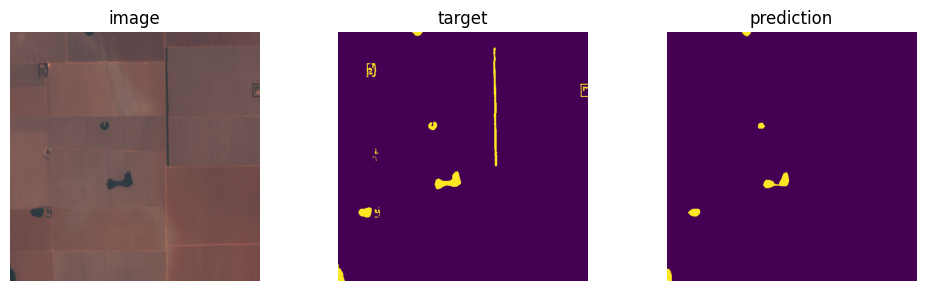

Visual example saved to `/home/mozi30/repos/private/CV_VisionStudio/notebooks/notebooks/outputs/image_segmentation/visual_examples/baseline_example.png`

In [11]:
def render_mask(mask: Tensor) -> Tensor:
    mask = mask.detach().cpu().float()
    if mask.numel() == 0:
        return mask
    return mask / max(float(mask.max().item()), 1.0)


try:
    image, target = raw_val_dataset[0]
    model.eval()
    with torch.no_grad():
        logits = model(normalize_image(image).unsqueeze(0).to(DEVICE))
        baseline_mask = model.postprocess(logits)["masks"].squeeze(0).cpu()
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    axes[0].imshow(tensor_to_pil_rgb(image))
    axes[0].set_title("image")
    axes[1].imshow(render_mask(target["mask"]), cmap="viridis")
    axes[1].set_title("target")
    axes[2].imshow(render_mask(baseline_mask), cmap="viridis")
    axes[2].set_title("prediction")
    for axis in axes:
        axis.axis("off")
    visual_path = VISUAL_DIR / "baseline_example.png"
    fig.tight_layout()
    fig.savefig(visual_path, dpi=150)
    plt.show()
    display(Markdown(f"Visual example saved to `{visual_path}`"))
except Exception as exc:
    display(Markdown(f"Visual example skipped: `{safe_error(exc)}`"))


### Run Completion Summary

Report completed and failed variant counts, identify the strongest completed compression result, and confirm the generated artifact locations and read-only treatment of source checkpoints.

In [12]:
completed = sum(1 for row in result_rows if row["status"] == "completed")
failed = len(result_rows) - completed
display(Markdown(f"""
**Run complete**

- Completed variants: `{completed}`
- Failed/skipped variants: `{failed}`
- Source dataset modified: `False`
- Source autoencoder directory modified: `False`
- Human review required for AI-generated dataset, model, metric, notebook, and interpretation code before accepting results.
"""))



**Run complete**

- Completed variants: `30`
- Failed/skipped variants: `0`
- Source dataset modified: `False`
- Source autoencoder directory modified: `False`
- Human review required for AI-generated dataset, model, metric, notebook, and interpretation code before accepting results.
